In [ ]:
Tries is a tree-like data structure used for storing a dynamic set of strings. it efficiently supports searching, inserting, and deleting words based on their prefixes.

Properties:
- The root node is empty ("").
- Each node represents a character.
- Each child of a node corresponds to a possible next character in the word.
- A boolean flag (is_end) is used to mark the end of a word.

Operations:
- Insert: Add a word by character
- Delete: Removes a word from Trie
- Search: Check if a word exist in Trie
- Prefix Search: Its like stratswith(x) 

Use Cases of Trie:
1.	Auto-complete System: Predicts words based on prefix.
2.	Spell Checker: Searches for words efficiently.
3.	IP Routing: Stores IP addresses in a structured manner.
4.	Dictionary Implementation: Quickly retrieves words.
5.	Data Compression: Reduces space by sharing prefixes.
6.	Longest Prefix Matching: Used in network routing.

Time Complexity
- Searching a word in python dict.
  - Best Case: O(N), lenght of word.
  - Worst Case: length of word * No. of words.

Trie
- Searching a word: T.C of insertion: height/ Length of the word * 26 
- To create a trie: max lenght of word * No. of words.

In [26]:
import json
from graphviz import Digraph

class TrieNode:
    def __init__(self):
        self.children = {}  # Dictionary to store child nodes
        self.is_end = False  # Flag to indicate end of a word

    def __str__(self):
        return f"_{self.children}_"


    def __repr__(self):
        return f"___{self.children}___"

class Trie:
    def __init__(self):
        self.root = TrieNode()  # Root node
    
    def insert(self, word):
        node = self.root
        for char in word:
            if char not in node.children:
                node.children[char] = TrieNode()  # Create new node if not present
            node = node.children[char]
        node.is_end = True  # Mark the last character as end of word

    def search(self, word):
        node = self.root
        for char in word:
            if char not in node.children:
                return False  # If any character is missing, word doesn't exist
            node = node.children[char]
        return node.is_end  # Return True if end of word is reached

    def startsWith(self, prefix):
        node = self.root
        for char in prefix:
            if char not in node.children:
                return False  # If any prefix character is missing
            node = node.children[char]
        return True  # Prefix exists in trie

    def delete(self, word):
        """
         In case of word delettion: The last letter of word (ie. the base condition of code) will initiate the word delete process.
             - When call stack has reached the limit, then the first callback (should_delete = True) and del the last letter.
             - After that, all the remaing characters will be removed if, the last line [len(node.children) == 0  # Return if current node is also deletable] is until true in reverse call stack.

        - If word does not exist, or the is_end of last character is false, then the word will not be deleted.
        """
        def _delete(node, word, index):
            if index == len(word):  # If end of the word is reached
                if not node.is_end:
                    return False  # Word does not exist
                node.is_end = False  # Unmark the word
                return len(node.children) == 0  # Delete if it has no children
            
            char = word[index]
            if char not in node.children:
                return False  # Word doesn't exist

            should_delete = _delete(node.children[char], word, index + 1)

            if should_delete:
                del node.children[char]  # Delete the child node if no dependency
                return len(node.children) == 0  # Return if current node is also deletable
            
            return False
        
        _delete(self.root, word, 0)  # Start recursive delete from root

    def visualize(self):
        dot = Digraph()
        dot.node("root", "ROOT")

        def add_edges(node, parent_label):
            for char, child in node.children.items():
                child_label = f"{parent_label}_{char}"
                dot.node(child_label, char, shape="circle")
                dot.edge(parent_label, child_label)
                add_edges(child, child_label)

        add_edges(self.root, "root")
        return dot

trie = Trie()
words = ["apple", "app", "apply", "bat", "banana"]
for word in words:
    trie.insert(word)




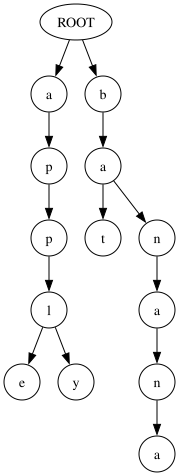

In [27]:
trie.root
trie.visualize()

In [ ]:
# Questions
1. Auto-Complete Feature: Given a list of words and a prefix, return all words that start with that prefix.
class TrieWithSuggestions(Trie):
    """
    It will go through the complete tree, even if a middle node has is_end=True.
    """
    def get_words_with_prefix(self, prefix):
        def dfs(node, path, result):
            if node.is_end:
                result.append("".join(path))
            for char, child in node.children.items():
                dfs(child, path + [char], result)
        
        node = self.root
        for char in prefix:
            if char not in node.children:
                return []  # No words with given prefix
            node = node.children[char]
        
        result = []
        dfs(node, list(prefix), result)
        return result

# Example usage:
trie = TrieWithSuggestions()
words = ["apple", "app", "apply", "bat", "banana"]
for word in words:
    trie.insert(word)

print(trie.get_words_with_prefix("app"))  # Output: ['app', 'apple', 'apply']



2. Longest Common Prefix: Given an array of words, find the longest common prefix.

def longest_common_prefix(self):
    prefix = ""
    node = self.root

    while len(node.children) == 1 and not node.is_end:
        char = list(node.children.keys())[0]  # Get the only child key
        prefix += char
        node = node.children[char]  # Move to the next node

    return prefix

3. 

In [38]:
3. Word Break Problem: Given a string s and a dictionary of words, check if s can be segmented into words from the dictionary

def word_break(s, word_dict):
    """ Here, If we found a word "cats", even still we have to check the complete substring.
      the last iteration of loop should be like
        - first sub-iteration, complete word.
        - second sub-iteratioin, return first letter and also if dp[first_letter] is true, then only check the sub-string without 1st character.
        - third sub-iteration, remove first 2 characters, check if first 2 characters are valid and remaining is valid.
        - 
        catsanddo. # Second last primary iteration with j is 0
        atsanddo
        tsanddo
        sanddo
        anddo
        nddo
        ddo
        do
        o
        catsanddog. # last primary iteration with j is 0
        [True, False, False, False, True, False, False, True, False, False, True]
    """
    trie = Trie()
    for word in word_dict:
        trie.insert(word)

    n = len(s)
    dp = [False] * (n + 1)
    dp[0] = True  # Base case

    for i in range(1, n + 1):
        for j in range(i):
            print(s[j:i])
            if dp[j] and trie.search(s[j:i]):
                dp[i] = True
                break

    print(dp)
    return dp[n]

# Example usage:
dictionary = ["cats", "and", "catsanddog"]
s = "catsanddog"
print(word_break(s, dictionary))  # Output: True

c
ca
a
cat
at
t
cats
catsa
atsa
tsa
sa
a
catsan
atsan
tsan
san
an
n
catsand
atsand
tsand
sand
and
catsandd
atsandd
tsandd
sandd
andd
ndd
dd
d
catsanddo
atsanddo
tsanddo
sanddo
anddo
nddo
ddo
do
o
catsanddog
[True, False, False, False, True, False, False, True, False, False, True]
True


In [ ]:
4. Count Words With Given Prefix

class TrieWithCount(Trie):
    def count_words_with_prefix(self, prefix):
        node = self.root
        for char in prefix:
            if char not in node.children:
                return 0  # No words with this prefix
            node = node.children[char]

        def count_nodes(node):
            count = 1 if node.is_end else 0
            for child in node.children.values():
                count += count_nodes(child)
            return count
        
        return count_nodes(node)

# Example usage:
trie = TrieWithCount()
words = ["car", "cart", "cat", "dog", "door"]
for word in words:
    trie.insert(word)

print(trie.count_words_with_prefix("ca"))  # Output: 3 ("car", "cart", "cat")

In [1]:
#5. Shortest Unique prefix for every word
class TrieNode:
    def __init__(self):
        self.children = {}
        self.count = 0  # Number of words passing through this node
        self.is_end = False

class Trie:
    def __init__(self):
        self.root = TrieNode()

    def insert(self, word):
        node = self.root
        for char in word:
            if char not in node.children:
                node.children[char] = TrieNode()
            node = node.children[char]
            node.count += 1  # Increment count when passing through this node
        node.is_end = True

    def find_shortest_unique_prefix(self, word):
        node = self.root
        prefix = []
        for char in word:
            prefix.append(char)
            node = node.children[char]
            if node.count == 1:  # Unique prefix found
                return "".join(prefix)
        return "".join(prefix)  # In case all characters are needed

def shortest_unique_prefix(words):
    trie = Trie()
    
    # Insert all words into Trie
    for word in words:
        trie.insert(word)
    
    # Find shortest unique prefix for each word
    return [trie.find_shortest_unique_prefix(word) for word in words]

# Example usage:
words = ["zebra", "dog", "duck", "dove"]
print(shortest_unique_prefix(words))  # Output: ['z', 'dog', 'du', 'dov']

['z', 'dog', 'du', 'dov']


In [ ]:
Problem Statement
	•	Given a list of N words, process Q queries where each query consists of a string X of fixed length M.
	•	For each query, return the number of words in the input that start and end with the given string X.

Approach
	1.	Iterate over all input words, check if first 3 characters is same as last 3 characters, if yes then insert the word into trie. else Ignore it.


In [ ]:
Bitwise Operation:
1. bit = (num >> i) & 1
    - It extracts the i-th bit from the number num.
    - bit = (13 >> 2) & 1 
        13      =  1101  (binary)
        13 >> 2 =  0011  (shift right by 2 places)
        0011 & 1 = 1     (extract last bit)

2. opposite_bit = 1 - bit
   - it just returns the opposite of given bit.
   - usecase:
        XOR gives 1 if bits are different:
        	•	0 ^ 1 = 1
        	•	1 ^ 0 = 1

3. best_match |= (1 << i)
  - It sets the i-th bit of best_match to 1.
  - Explanation
	•	1 << i: Shifts 1 to the left by i places, creating a binary number where only the i-th bit is 1.
	•	best_match |= ...: Uses bitwise OR (|=) to set that bit in best_match.

class Geek():
    def __init__(self, value):
        self.value = value

    def __and__(self, obj):
        print("And operator overloaded")
        if isinstance(obj, Geek):
            return self.value & obj.value
        else:
            raise ValueError("Must be a object of class Geek")

    def __or__(self, obj):
        print("Or operator overloaded")
        if isinstance(obj, Geek):
            return self.value | obj.value
        else:
            raise ValueError("Must be a object of class Geek")

    def __xor__(self, obj):
        print("Xor operator overloaded")
        if isinstance(obj, Geek):
            return self.value ^ obj.value
        else:
            raise ValueError("Must be a object of class Geek")

    def __lshift__(self, obj):
        print("lshift operator overloaded")
        if isinstance(obj, Geek):
            return self.value << obj.value
        else:
            raise ValueError("Must be a object of class Geek")

    def __rshift__(self, obj):
        print("rshift operator overloaded")
        if isinstance(obj, Geek):
            return self.value >> obj.value
        else:
            raise ValueError("Must be a object of class Geek")

    def __invert__(self):
        print("Invert operator overloaded")
        return ~self.value


# Driver's code
if __name__ == "__main__":
    a = Geek(10)
    b = Geek(12)
    print(a & b)
    print(a | b)
    print(a ^ b)
    print(a << b)
    print(a >> b)
    print(~a)

In [ ]:
Given an array arr, find the pair (x, y) such that x ^ y is maximized.


class TrieNode:
    def __init__(self):
        self.children = {}  # '0' and '1'
        self.value = None   # Stores the actual number at leaf

class Trie:
    def __init__(self):
        self.root = TrieNode()

    def insert(self, num):
        """ Construct a Trie with the binary 0, 1 representation of all number.
        It will look like a binary tree, each node has 2 nodes 0 and 1.
        """
        node = self.root
        for i in range(31, -1, -1):  # Store 32-bit representation
            bit = (num >> i) & 1
            if bit not in node.children:
                node.children[bit] = TrieNode()
            node = node.children[bit]
        node.value = num  # Store the actual number at leaf

    def find_max_xor_pair(self, num):
        """ Here we will create a new number 

        """
        node = self.root
        best_match = 0
        for i in range(31, -1, -1):
            bit = (num >> i) & 1
            opposite_bit = 1 - bit  # Try to maximize XOR
            if opposite_bit in node.children:
                best_match |= (1 << i)  # Set bit in result
                node = node.children[opposite_bit]
            else:
                node = node.children[bit]
        return best_match

def find_max_xor_pair(arr):
    trie = Trie()
    max_xor = 0
    x, y = 0, 0

    # Insert numbers into Trie
    for num in arr:
        trie.insert(num)

    # Find maximum XOR pair
    for num in arr:
        best_match = trie.find_max_xor_pair(num)
        current_xor = num ^ best_match
        if current_xor > max_xor:
            max_xor = current_xor
            x, y = num, best_match

    return (x, y, max_xor)

# Example Usage
arr = [3, 10, 5, 25, 2, 8]
print(find_max_xor_pair(arr))  # Output: (5, 25, 28)

In [ ]:
Given an array arr, find the sub-array having maximum XOR.

Solution 1: Without using Trie, 

def maxSubarrayXOR(arr,n):

    """ TC: N^2
    Find XOR of all possible sub-arrays and take maximum of all.
    """
    ans = -2147483648 
    for i in range(n):
        curr_xor = 0
        for j in range(i,n):         
            curr_xor = curr_xor ^ arr[j]
            ans = max(ans, curr_xor)
         
    return ans

Solution 2: Using Trie,
Additional, To print first and last index of sub-array, we can add one more field to Trie node to achieve this 

def maxSubarrayXOR(arr,n):

    """ TC: N
    Find XOR of all possible sub-arrays and take maximum of all.
    """
    ans = -2147483648 
    for i in range(n):
        curr_xor = 0
        for j in range(i,n):         
            curr_xor = curr_xor ^ arr[j]
            ans = max(ans, curr_xor)
         
    return ans


In [ ]:
Offline Queries with Tries
https://www.naukri.com/code360/problems/max-xor-queries_1382020

- You are given an array/list ‘ARR’ of numbers. You are also given a list ‘QUERIES’ consisting of ‘M’ queries,  ‘QUERIES[i]’ = [‘Xi’, ‘Ai’].
The answer to the ith query, i.e ‘QUERIES[i]’ is the maximum bitwise xor value of ‘Xi’ with any integer less than or equal to ‘Ai’ in ‘ARR’.
You should return an array/list consisting of ‘N’ integers where the ‘i-th’ integer is the answer of ‘QUERIES[i]’.
----Query 1-----
5 2
0 1 2 3 4
1 3
Answer is 1 (given) ^ 2 (which is less than 3) = 3
-----Query 2-----
1 1
1
1 0  
Answer is -1

Intuttion: 
1. We just have to find the a number in array having maximum XOR with given number (ie 1)
2. All the numbers in Trie should be less than Ai ie. 3

Solution: Offline Queries concept, sort the given queries in an acending order and also remember the postions, 
          solve each query and save ouput in an array as per the initial ordering.

"""
    Time Complexity : O(N*(log(N)) + M*(log(M))), as initial sorting of array and queries is required.
    Space Complexity : O(N + M)
"""


class TrieNode:
    def __init__(self):
        self.children = [None, None]


def insert(root, num):
    ptr = root

    for i in range(30, -1, -1):
        if num & (1 << i):
            if ptr.children[1] == None:
                ptr.children[1] = TrieNode()
            ptr = ptr.children[1]
        else:
            if ptr.children[0] == None:
                ptr.children[0] = TrieNode()
            ptr = ptr.children[0]


def maxXorQueries(arr, queries):
    
    #  Size of array and number of queries.
    n = len(arr)
    m = len(queries)

    result = [-1]*m
    order = [0]*m

    #  Sort â€˜arrâ€™ in non-decreasing order.
    arr.sort()

    for i in range(0, m):
        order[i] = i

    #  for offline queries, Order in which queries will be processed.
    order.sort(key=lambda x: queries[x][1])

    root = TrieNode()
    p = 0

    #  Finding answer of each query.
    for i in range(0, m):

        #  Index of query process in current iteration.
        id = order[i]

        #  Insert integers of 'arr' smaller or equal to queries[id][1] in trie.
        while p < n and arr[p] <= queries[id][1]:
            insert(root, arr[p])
            p = p + 1

        #  If trie is empty then answer to this query is -1.
        if root.children[0] == None and root.children[1] == None:
            continue

        ptr = root
        ans = 0

        ans = find_max_xor(queries[id][0])
        result[id] = ans

    return result


In [ ]:
Find a sub-array having maximum XOR.
Solution: Iterate over array, insert all prefix_XOR in Trie (all starting from index zero). Also find the maximum possible XOR 
for the sub-arry ending with i th postion.

Intution: In last iteration, when A[0:N], till that time, we have already inserted all sub-array starting from index zero.
- maxXOR() will check, A[0:N] with all the prefix_XOR subarray, starting from index zero.
- In single maxXOR() it will check, A[0:N] with , A[0], A[0:2], A[0:3], A[0:4], A[0:5], ...
    
class TrieNode:
    def __init__(self):
        self.children = {}
        self.value = 0

class Trie:
    def __init__(self):
        self.root = TrieNode()

    def insert(self, num):
        node = self.root
        for i in range(31, -1, -1):  # Traverse bits from MSB to LSB
            bit = (num >> i) & 1
            if bit not in node.children:
                node.children[bit] = TrieNode()
            node = node.children[bit]
        node.value = num

    def maxXOR(self, num):
        node = self.root
        max_xor = 0
        for i in range(31, -1, -1):
            bit = (num >> i) & 1
            opposite_bit = 1 - bit  # Try to find the opposite bit
            if opposite_bit in node.children:
                max_xor |= (1 << i)  # Set bit in result
                node = node.children[opposite_bit]
            else:
                node = node.children[bit]
        return max_xor

def maxSubarrayXOR(arr):
    trie = Trie()
    trie.insert(0)  # Insert prefix XOR = 0
    max_xor = 0
    prefix_xor = 0

    for num in arr:
        prefix_xor ^= num  # Compute prefix XOR
        trie.insert(prefix_xor)  # Insert into Trie
        max_xor = max(max_xor, trie.maxXOR(prefix_xor))  # Query Trie

    return max_xor

# Example Usage:
arr = [8, 1, 2, 12]
print("Max subarray XOR is:", maxSubarrayXOR(arr))  # Output: 15